In [1]:
import torch

In [2]:
import sys
import os
sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))

from akita_model.model import SeqNN

In [3]:
import ast

In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [5]:
model = SeqNN()
model.load_state_dict(torch.load("/scratch1/smaruj/Akita_pytorch_models/finetuned/mouse_models/"
    "Hsieh2019_mESC/models/Akita_v2_mouse_Hsieh2019_mESC_model0_finetuned.pth", map_location=device))
model.eval()

SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 128, kernel_size=(15,), stride=(1,), padding=(7,), bias=False)
    (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size=2, stride=2, paddi

In [6]:
import pandas as pd

In [7]:
FOLD = 0

In [8]:
df = pd.read_csv(f"/scratch1/smaruj/suppressing_CTCFs/fold{FOLD}_with_positions.tsv", sep="\t")

In [9]:
boundary_mask_path = "/scratch1/smaruj/generate_genomic_boundary/boundary_indices.pt"

In [10]:
import sys
sys.path.insert(0, "/home1/smaruj/ledidi")
from ledidi import Ledidi

In [11]:
bin_size = 2048
cropping_applied = 64
padding_bins = 2
padding = padding_bins * bin_size

slice_0_bins = [256]
# slice_0_bins = [i for i in range(231, 281)]
slice_0_start = (min(slice_0_bins) + cropping_applied - padding_bins) * bin_size
slice_0_end = (max(slice_0_bins) + 1 + cropping_applied + padding_bins) * bin_size

In [ ]:
# df

In [12]:
c = -0.5

In [13]:
import numpy as np

In [14]:
# Helper function to set diagonal elements to a specific value
def set_diag(matrix, value, k):
    # Explicitly set the diagonal to 'value' (in this case, np.nan) for each k
    rows, cols = matrix.shape
    for i in range(rows):
        if 0 <= i + k < cols:
            matrix[i, i + k] = value


def from_upper_triu(vector_repr, matrix_len, num_diags):
    # Ensure vector_repr is a NumPy array (if it's a PyTorch tensor, convert it)
    if isinstance(vector_repr, torch.Tensor):
        vector_repr = vector_repr.detach().flatten().cpu().numpy()  # Flatten and convert to NumPy array

    # Initialize a zero matrix of shape (matrix_len, matrix_len)
    z = np.zeros((matrix_len, matrix_len))

    # Get the indices for the upper triangular matrix
    triu_tup = np.triu_indices(matrix_len, num_diags)

    # Assign the values from the vector_repr to the upper triangular part of the matrix
    z[triu_tup] = vector_repr

    # Set the diagonals specified by num_diags to np.nan
    for i in range(-num_diags + 1, num_diags):
        set_diag(z, np.nan, i)

    # Ensure the matrix is symmetric
    return z + z.T

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
def plot_map(matrix, vmin=-0.6, vmax=0.6, palette="RdBu_r", width=5, height=5):
    fig, axes = plt.subplots(1, 1, figsize=(width, height))

    sns.heatmap(
        matrix,
        vmin=vmin,
        vmax=vmax,
        cbar=False,
        cmap=palette,
        square=True,
        xticklabels=False,
        yticklabels=False,
        ax=axes
    )

    plt.tight_layout()
    plt.show()

In [17]:
def build_ctcf_input_mask(seq_len, ctcf_locs, flanking=15):
    """
    Build a boolean mask tensor indicating CTCF regions + optional flanking bases.

    Args:
        seq_len (int): total length of the sequence (number of positions).
        ctcf_locs (list of tuples): list of (start, end) positions of CTCF sites (0-based, end exclusive).
        flanking (int): number of bases to also mask on each side of the site (default 15).

    Returns:
        torch.BoolTensor: mask of shape (seq_len,) where True means "masked / not editable".
    """
    mask = torch.zeros(seq_len, dtype=torch.bool)
    
    for start, end in ctcf_locs:
        # Apply flanking region, clamp to sequence boundaries
        start_flank = max(0, start - flanking)
        end_flank = min(seq_len, end + flanking)
        
        mask[start_flank:end_flank] = True
    
    return mask

In [18]:
CTCF_PWM = "/home1/smaruj/IterativeMutagenesis/MA0139.1.meme"

In [19]:
def read_meme_pwm_as_numpy(filename):
    pwm_list = []  # List to store PWM rows
    
    with open(filename, 'r') as file:
        in_matrix_section = False
        
        for line in file:
            line = line.strip()
            
            # Check if we are reading the PWM matrix
            if line.startswith("letter-probability matrix"):
                in_matrix_section = True  # Start reading matrix data
                continue  # Skip this header line
            
            # If we are in the matrix section, process the rows
            if in_matrix_section and line:
                pwm_row = [float(value) for value in line.split()]  # Parse values
                pwm_list.append(pwm_row)  # Append to the PWM list
            
            # If we encounter a new MOTIF or the end of file, stop matrix reading
            if line.startswith("MOTIF") and in_matrix_section:
                break
    
    # Convert the list to a numpy array
    pwm_array = np.array(pwm_list)
    
    return pwm_array

In [20]:
pwm_CTCF = read_meme_pwm_as_numpy(CTCF_PWM)
pwm_CTCF_tensor = torch.from_numpy(pwm_CTCF.T).float()
motifs_dict = {"CTCF": pwm_CTCF_tensor}

In [21]:
gamma = 100.0

In [ ]:
50 * 2048

CTCFs suppressing for genome location: chr3:53286912-54597632


/home1/smaruj/miniconda3/envs/pytorch_hic/lib/python3.10/site-packages/torch/nn/modules/conv.py:306: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:84.)
  return F.conv1d(input, weight, bias, self.stride,


Matrix before


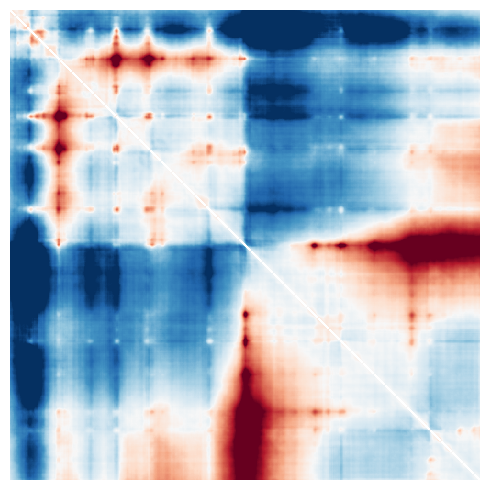

Model in train mode: False
Gradients enabled for weights - slice 0: True
Weights shape - slice 0: torch.Size([1, 4, 2048])
Local loss applied.
iter=I	input_loss=0.0	output_loss=2.113e+04	total_loss=2.113e+04	time=0.0
iter=100	input_loss=599.0	output_loss=9.532e+03	total_loss=2.384e+04	time=10.36
iter=200	input_loss=723.0	output_loss=7.183e+03	total_loss=1.937e+04	time=10.15
iter=300	input_loss=772.0	output_loss=6.789e+03	total_loss=1.837e+04	time=10.51
iter=400	input_loss=781.0	output_loss=6.606e+03	total_loss=1.819e+04	time=10.17
iter=500	input_loss=803.0	output_loss=6.559e+03	total_loss=1.896e+04	time=10.42
iter=600	input_loss=827.0	output_loss=6.584e+03	total_loss=1.925e+04	time=10.19
iter=700	input_loss=826.0	output_loss=6.514e+03	total_loss=1.955e+04	time=10.32
iter=800	input_loss=840.0	output_loss=6.541e+03	total_loss=1.959e+04	time=10.15
iter=900	input_loss=866.0	output_loss=6.507e+03	total_loss=1.9e+04	time=10.09
iter=1000	input_loss=839.0	output_loss=6.518e+03	total_loss=1.867

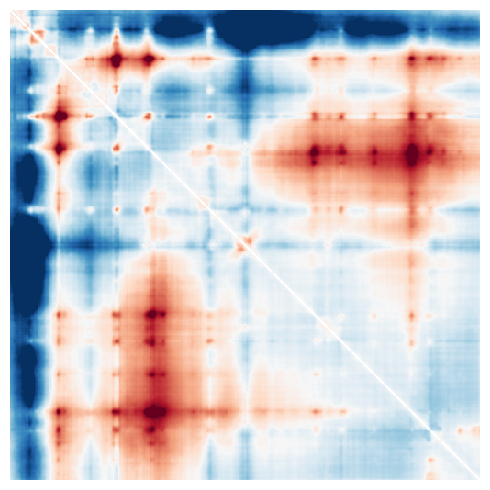

In [22]:
for row in df[3:4].itertuples(index=False):
    chrom, pred_start, pred_end = row.chrom, row.centered_start, row.centered_end
    
    print(f"CTCFs suppressing for genome location: {chrom}:{pred_start}-{pred_end}")
    
    ctcf_locations = ast.literal_eval(row.ctcf_motif_locs)
    
    input_mask = build_ctcf_input_mask(2048, ctcf_locations, 15).to(device=device)
    # input_mask = build_ctcf_input_mask(102400, ctcf_locations, 15).to(device=device)
    
    X = torch.load(f"/scratch1/smaruj/suppressing_CTCFs/ohe_X/fold0/{chrom}_{pred_start}_{pred_end}_X.pt", weights_only=True, map_location=device)
    target = torch.load(f"/scratch1/smaruj/suppressing_CTCFs/targets/target_-0.5/fold{FOLD}/{chrom}_{pred_start}_{pred_end}_target.pt", weights_only=True, map_location=device)
    tower_output_path = f"/scratch1/smaruj/suppressing_CTCFs/tower_outputs/fold0/{chrom}_{pred_start}_{pred_end}_tower_out.pt"
    
    model.eval()
    with torch.no_grad():
        pred_before = model(X)
    
    matrix_to_plot_before = from_upper_triu(pred_before[0, 0, :], matrix_len=512, num_diags=2)
    
    print("Matrix before")
    plot_map(matrix_to_plot_before)
    
    wrapper = Ledidi(model, 
                 input_loss=torch.nn.L1Loss(reduction='sum'), 
                 output_loss=torch.nn.L1Loss(reduction='sum'),
                 batch_size=1,
                #  l=10.0,
                 l=0.1,
                 max_iter=2000,
                 early_stopping_iter=2000,
                 return_history=True,
                 verbose=True,
                 bin_size=2048,
                 input_mask_slices_0=[256], # mid-bin
                #  input_mask_slices_0=[i for i in range(231, 281)],
                 cropping_applied=64,
                 output_mask_path=boundary_mask_path,
                 use_semifreddo=True,
                 semifreddo_temp_output_path=tower_output_path,
                 g=gamma,
                 punish_ctcf=True,
                 ctcf_meme_path=CTCF_PWM,
                 suppressing_mask=input_mask
                 ).cuda()
    
    slice_0_torch = X[:, :, slice_0_start:slice_0_end]
    
    x_bar_slice_0, history = wrapper.fit_transform(X=slice_0_torch, y_bar=target)
    
    X_new = X.clone()
    X_new[:,:,slice_0_start:slice_0_end] = x_bar_slice_0
    
    model.eval()
    with torch.no_grad():
        pred_after = model(X_new)
    
    matrix_to_plot_after = from_upper_triu(pred_after[0, 0, :], matrix_len=512, num_diags=2)
    
    print("Matrix after")
    plot_map(matrix_to_plot_after)
    

In [ ]:
plt.figure(figsize=(8, 8))
plt.matshow(matrix_to_plot_before.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
plt.colorbar()
# plt.savefig("map_before.svg", format='svg')
plt.show()

In [ ]:
plt.figure(figsize=(8, 8))
plt.matshow(matrix_to_plot_after.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
plt.colorbar()
# plt.savefig("map_after.svg", format='svg')
plt.show()

In [ ]:
plt.figure(figsize=(8, 8))
plt.matshow(matrix_to_plot_after-matrix_to_plot_before.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
plt.colorbar()
# plt.savefig("map_difference.svg", format='svg')
plt.show()

In [ ]:
# df

In [ ]:
chr3:53286912-54597632

In [23]:
# original DNA seq

path = "/scratch1/smaruj/generate_genomic_boundary/ohe_X/fold0/chr3_53286912_54597632_X.pt"

# Load tensor
ohe_seq = torch.load(path)

In [ ]:
model.eval()
with torch.no_grad():
    pred_genomic = model(ohe_seq)

In [ ]:
matrix_genomic = from_upper_triu(pred_genomic[0, 0, :], matrix_len=512, num_diags=2)

In [ ]:
plt.figure(figsize=(8, 8))
plt.matshow(matrix_genomic.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
plt.colorbar()
# plt.savefig("map_genomic.svg", format='svg')
plt.show()

In [ ]:
for key in history:
    print(key)

In [ ]:
edit_positions = history["edit_positions"][:]

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Convert your list of lists (each of length 2048) to a 2D array
edit_array = np.array(edit_positions)  # shape: (len, 2048)
input_mask_np = input_mask.detach().cpu().numpy()
input_mask = np.array(input_mask_np)  # shape: (2048,), True = no edits allowed

plt.figure(figsize=(15, 6))
plt.imshow(edit_array, aspect='auto', cmap='Greys', interpolation='none')

# Overlay red vertical lines where input_mask is True
for pos in np.where(input_mask)[0]:
    plt.axvline(x=pos, color='red', alpha=0.2, linewidth=0.5)

plt.xlabel('Sequence Position')
plt.ylabel('Iteration')
plt.title('Edit Positions Over Optimization Steps')
plt.colorbar(label='Edit (1) / No Edit (0)')
plt.tight_layout()
plt.show()

In [ ]:
input_mask

In [ ]:
# from pyfaidx import Fasta

In [ ]:
# fasta_file = "/project/fudenber_735/genomes/mm10/mm10.fa"
# genome = Fasta(fasta_file)

In [ ]:
CTCF_PWM = "/home1/smaruj/IterativeMutagenesis/MA0139.1.meme"

In [ ]:
def read_meme_pwm_as_numpy(filename):
    pwm_list = []  # List to store PWM rows
    
    with open(filename, 'r') as file:
        in_matrix_section = False
        
        for line in file:
            line = line.strip()
            
            # Check if we are reading the PWM matrix
            if line.startswith("letter-probability matrix"):
                in_matrix_section = True  # Start reading matrix data
                continue  # Skip this header line
            
            # If we are in the matrix section, process the rows
            if in_matrix_section and line:
                pwm_row = [float(value) for value in line.split()]  # Parse values
                pwm_list.append(pwm_row)  # Append to the PWM list
            
            # If we encounter a new MOTIF or the end of file, stop matrix reading
            if line.startswith("MOTIF") and in_matrix_section:
                break
    
    # Convert the list to a numpy array
    pwm_array = np.array(pwm_list)
    
    return pwm_array

In [24]:
pwm_CTCF = read_meme_pwm_as_numpy(CTCF_PWM)
pwm_CTCF_tensor = torch.from_numpy(pwm_CTCF.T).float()
motifs_dict = {"CTCF": pwm_CTCF_tensor}

In [25]:
from memelite import fimo

In [ ]:
320 * 2048

In [29]:
original_hits = fimo(
    motifs=motifs_dict,
    sequences=X[:, :, 655360:655360+2048].cpu().detach().numpy(),
    threshold=1e-4,
    reverse_complement=True
)[0]

In [31]:
ctcf_locations

[(950, 969), (1026, 1045), (1424, 1443), (1931, 1950)]

In [32]:
original_hits

,motif_name,motif_idx,sequence_name,start,end,strand,score,p-value
0,CTCF,0,0,950,969,+,21.473820,3.108289e-08
1,CTCF,0,0,1026,1045,+,22.009017,1.713852e-08
2,CTCF,0,0,1424,1443,-,9.785917,5.589463e-05
3,CTCF,0,0,1931,1950,-,21.631713,2.557135e-08


In [30]:
updated_hits = fimo(
    motifs=motifs_dict,
    sequences=x_bar_slice_0[:, :, 4096:-4096].cpu().detach().numpy(),
    threshold=1e-4,
    reverse_complement=True
)[0]

In [33]:
updated_hits

,motif_name,motif_idx,sequence_name,start,end,strand,score,p-value
0,CTCF,0,0,950,969,+,21.473820,3.108289e-08
1,CTCF,0,0,1026,1045,+,22.009017,1.713852e-08
2,CTCF,0,0,809,828,-,18.069560,5.195543e-07
3,CTCF,0,0,1176,1195,-,13.438657,8.990835e-06
4,CTCF,0,0,1424,1443,-,9.785917,5.589463e-05
5,CTCF,0,0,1931,1950,-,21.631713,2.557135e-08


In [ ]:
edit_array = np.array(edit_positions)  # shape: (2763, 2048)

plt.figure(figsize=(15, 6))
plt.imshow(edit_array, aspect='auto', cmap='Greys', interpolation='none')

plotting_flank = 15

# Plot vertical shaded regions for CTCF motif positions
for _, row in original_hits.iterrows():
    start = row['start']
    end = row['end']
    plt.axvspan(start-plotting_flank, end+plotting_flank , color='red', alpha=0.3)

plt.xlabel('Sequence Position')
plt.ylabel('Iteration')
plt.title('Edit Positions Over Time with CTCF Motifs')
plt.colorbar(label='Edit (1) / No Edit (0)')

plt.tight_layout()
plt.show()

In [ ]:
# Convert to sets of (start, end) for comparison
original_coords = set(zip(original_hits["start"], original_hits["end"]))
updated_coords = set(zip(updated_hits["start"], updated_hits["end"]))

# Identify new hits in updated_hits
new_coords = updated_coords - original_coords
new_hits = updated_hits[updated_hits.apply(lambda r: (r["start"], r["end"]) in new_coords, axis=1)]

In [ ]:
new_hits.sort_values(by="start")

In [ ]:
# Plot the edit array
plt.figure(figsize=(15, 6))
plt.imshow(edit_array, aspect="auto", cmap="Greys", interpolation="none")

plotting_flank = 15

# Plot red spans = original hits
for _, row in original_hits.iterrows():
    start, end = row["start"], row["end"]
    plt.axvspan(start - plotting_flank, end + plotting_flank, color="red", alpha=0.3)

for _, row in original_hits.iterrows():
    start, end = row["start"], row["end"]
    plt.axvspan(start, end, color="red", alpha=0.3)

# Plot green spans = new hits only in updated_hits
for _, row in new_hits.iterrows():
    start, end = row["start"], row["end"]
    plt.axvspan(start, end, color="green", alpha=0.3)

plt.xlabel("Sequence Position")
plt.ylabel("Iteration")
plt.title("Edit Positions Over Time with CTCF Motifs")
plt.colorbar(label="Edit (1) / No Edit (0)")

plt.tight_layout()
plt.show()